<a href="https://colab.research.google.com/github/raj143sujay/EXCELR-ASSIGNMENTS/blob/main/NLP_Sentiment_Analysis(P684)Naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel("dataset -P684.xlsx")
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [6]:
df.shape

(1440, 3)

In [7]:
df.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [8]:
df.isnull().sum()

,0
title,0
rating,0
body,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df.dropna(inplace=True)

In [12]:
print(df.columns.tolist())

['title', 'rating', 'body']


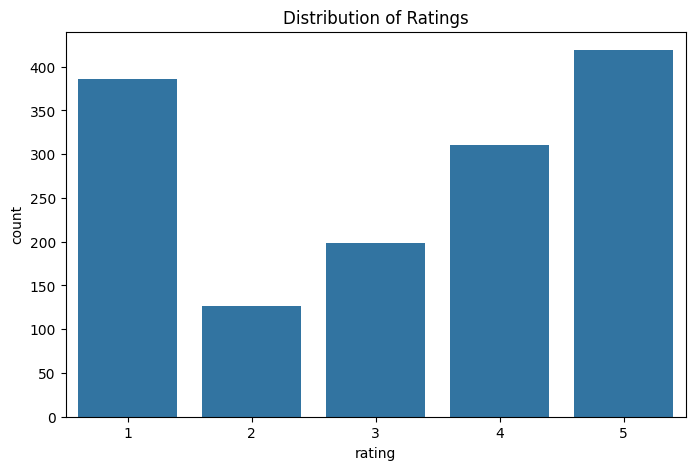

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=df)
plt.title("Distribution of Ratings")
plt.show()

In [14]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(sentiment_label)

df.head()

,title,rating,body,sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative


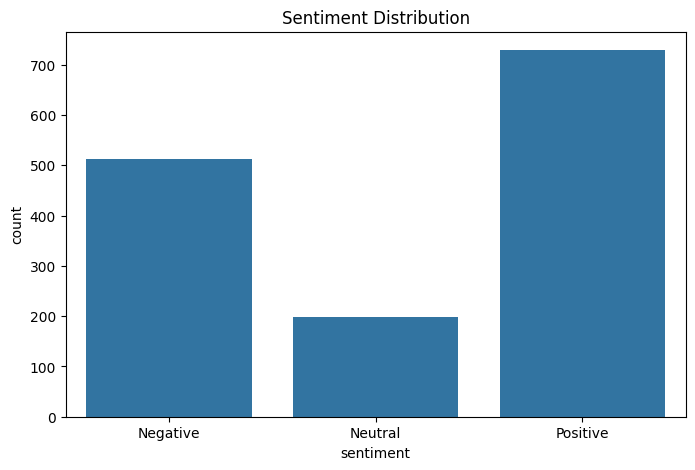

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [16]:
df["review_length"] = df["body"].astype(str).apply(len)

df["review_length"].describe()

,review_length
count,1440.000000
mean,302.109028
std,225.733052
min,4.000000
25%,170.000000
50%,246.000000
75%,359.000000
max,2490.000000


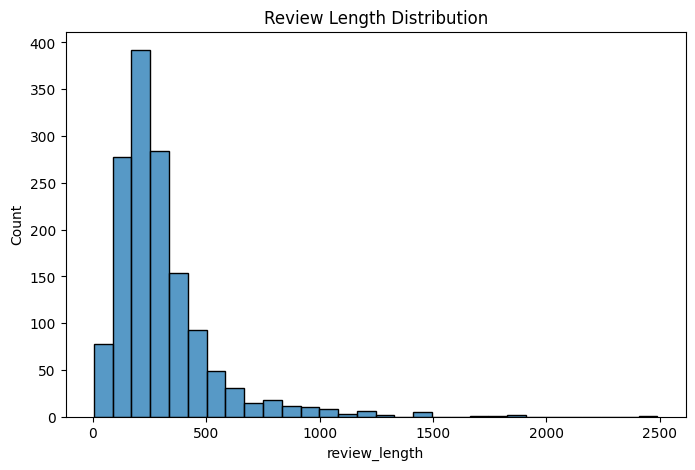

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["review_length"], bins=30)
plt.title("Review Length Distribution")
plt.show()

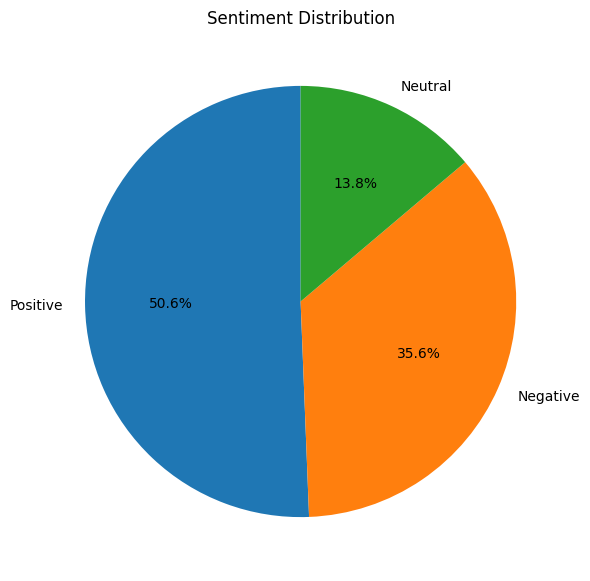

In [18]:
plt.figure(figsize=(7,7))

df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

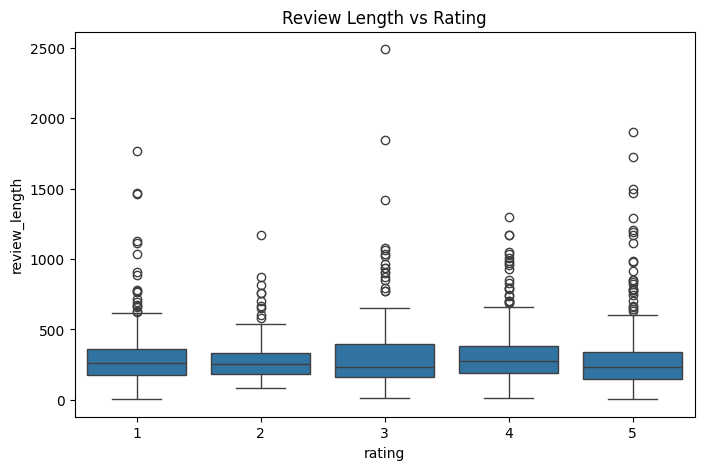

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='rating',
    y='review_length',
    data=df
)

plt.title("Review Length vs Rating")
plt.show()

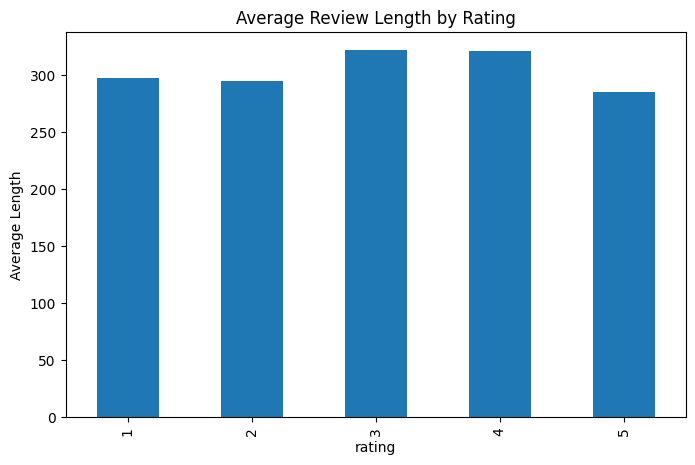

In [20]:
avg_length = df.groupby('rating')['review_length'].mean()

plt.figure(figsize=(8,5))

avg_length.plot(kind='bar')

plt.title("Average Review Length by Rating")
plt.ylabel("Average Length")
plt.show()

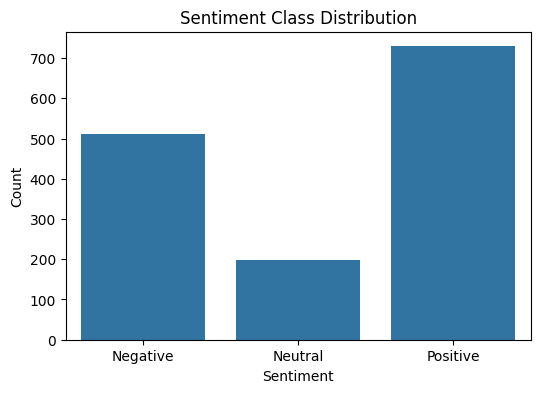

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [22]:
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [23]:
#Lower Case
df['clean_review'] = df['body'].astype(str).str.lower()

df[['body','clean_review']].head()

,body,clean_review
0,Very disappointed with the overall performance...,very disappointed with the overall performance...
1,Camera quality is low,camera quality is low
2,"Got the mobile on the launch date,Battery must...","got the mobile on the launch date,battery must..."
3,1. It doesn't work with 5.0GHz WiFi frequency....,1. it doesn't work with 5.0ghz wifi frequency....
4,"Not worth buying....faulty software, poor disp...","not worth buying....faulty software, poor disp..."


In [24]:
#Remove Urls
df['clean_review'] = df['clean_review'].apply(
    lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x)
)

In [25]:
#Remove HTML
df['clean_review'] = df['clean_review'].apply(
    lambda x: re.sub(r'<.*?>', '', x)
)

In [26]:
#Remove Numbers
df['clean_review'] = df['clean_review'].apply(
    lambda x: re.sub(r'\d+', '', x)
)

In [27]:
#Remove Punctuation
df['clean_review'] = df['clean_review'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

In [28]:
#Remove Extra Spaces
df['clean_review'] = df['clean_review'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

In [29]:
#Tokenization
df['tokens'] = df['clean_review'].apply(lambda x: x.split())

In [30]:
#Stopwords Removal
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [31]:
#Lemmatization
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [32]:
df['clean_review'] = df['tokens'].apply(lambda words: " ".join(words))

df[['clean_review']].head()

,clean_review
0,disappointed overall performance samsung
1,camera quality low
2,got mobile launch datebattery must appreciated...
3,doesnt work ghz wifi frequency ghz old school ...
4,worth buyingfaulty software poor display quali...


In [33]:
df.drop(columns='tokens', inplace=True)

df.head()

,title,rating,body,sentiment,review_length,clean_review
0,Horrible product,1,Very disappointed with the overall performance...,Negative,59,disappointed overall performance samsung
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,21,camera quality low
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,403,got mobile launch datebattery must appreciated...
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,377,doesnt work ghz wifi frequency ghz old school ...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,179,worth buyingfaulty software poor display quali...


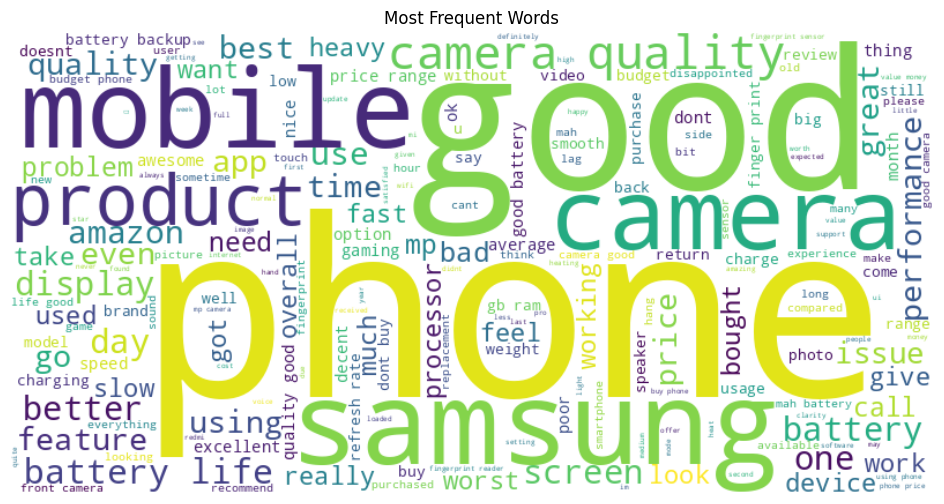

In [34]:
from wordcloud import WordCloud

text = " ".join(df["clean_review"].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

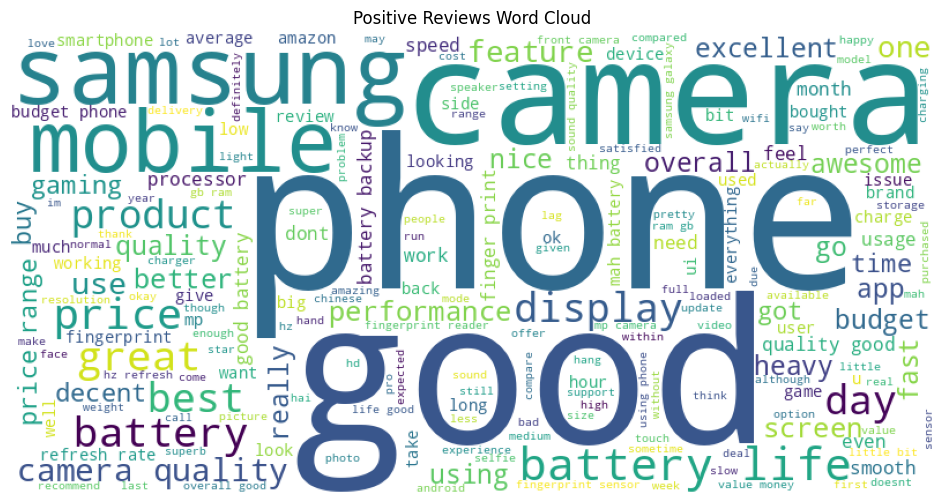

In [35]:
positive_text = " ".join(
    df[df['sentiment']=='Positive']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

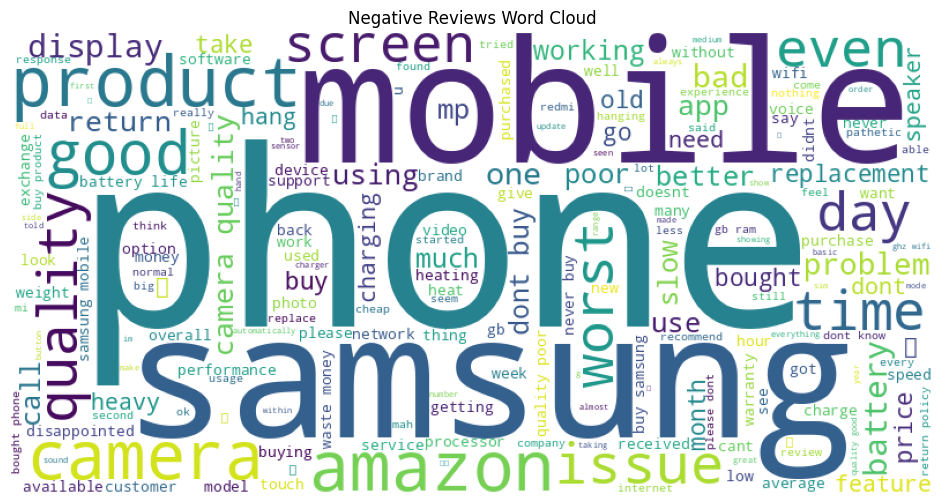

In [36]:
negative_text = " ".join(
    df[df['sentiment']=='Negative']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

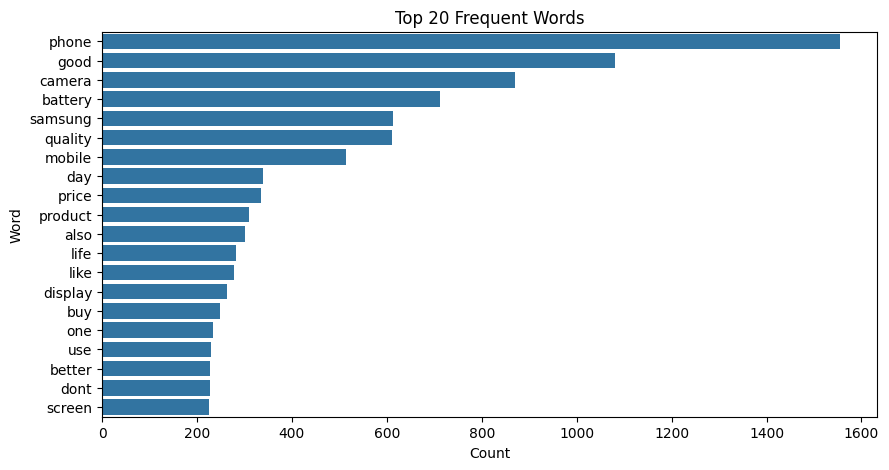

In [37]:
from collections import Counter

all_words = " ".join(df["clean_review"]).split()

word_freq = Counter(all_words)

common_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['Word','Count']
)

plt.figure(figsize=(10,5))
sns.barplot(
    x='Count',
    y='Word',
    data=common_words
)
plt.title("Top 20 Frequent Words")
plt.show()

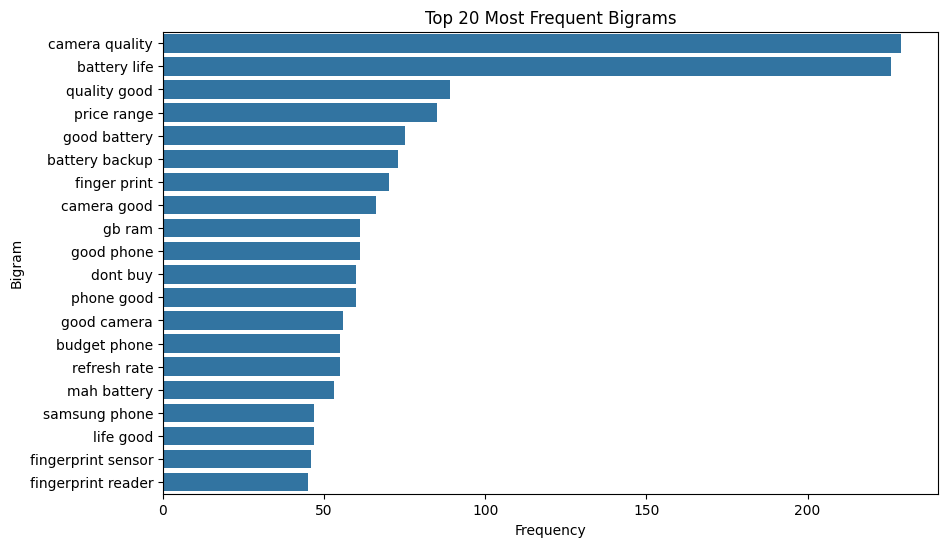

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')

X = vectorizer.fit_transform(df['clean_review'].dropna())

bigram_counts = X.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['Bigram', 'Count']
)

bigram_df = bigram_df.sort_values(
    by='Count',
    ascending=False
).head(20)
plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x='Count',
    y='Bigram'
)

plt.title("Top 20 Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

In [39]:
sentiment_percentage = (
    df['sentiment']
    .value_counts(normalize=True)*100
)

print(sentiment_percentage)

sentiment
Positive    50.625000
Negative    35.555556
Neutral     13.819444
Name: proportion, dtype: float64


In [40]:
correlation = df['rating'].corr(df['review_length'])
print("Correlation:", correlation)

Correlation: -0.007968593212022075


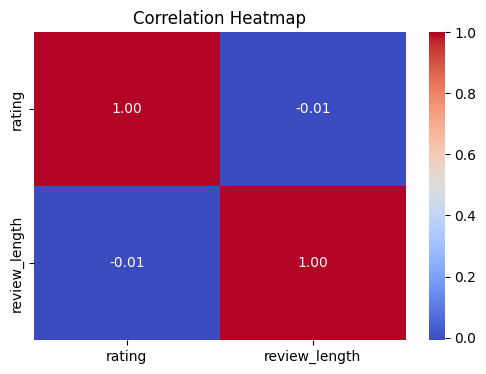

In [41]:
corr_matrix = df[['rating', 'review_length']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [42]:
# Feature (Input)
X = df['clean_review']

# Target (Output)
y = df['sentiment']

print("Number of samples:", len(X))

Number of samples: 1440


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 1152
Testing samples  : 288


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training Shape :", X_train_tfidf.shape)
print("Testing Shape  :", X_test_tfidf.shape)

Training Shape : (1152, 5000)
Testing Shape  : (288, 5000)


In [45]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['aanel kanikund' 'aap' 'aap hi' 'aap net' 'aap sab' 'aaya' 'aaya tha'
 'ab' 'ab jab' 'abhi' 'abhi dinon' 'abide' 'abide indian' 'able'
 'able attend' 'able connect' 'able hear' 'able return' 'abruptly'
 'absolute' 'absolutely' 'absolutely fine' 'accept' 'accept return'
 'acceptable' 'access' 'accha' 'according' 'according price' 'accurate']


In [46]:
tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aanel kanikund,aap,aap hi,aap net,aap sab,aaya,aaya tha,ab,ab jab,abhi,...,പള പണ,പൻ,പൻ ധന,യത,യത gb,യല,ലത,ലത എന,വയമ,വയമ പൻ
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 5000


In [48]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluate the model
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nNaive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.63      0.71       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.68      0.98      0.80       146

    accuracy                           0.72       288
   macro avg       0.50      0.54      0.50       288
weighted avg       0.64      0.72      0.66       288


Naive Bayes Confusion Matrix:
[[ 64   0  38]
 [ 11   0  29]
 [  3   0 143]]

Naive Bayes Accuracy: 0.71875


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.74      0.73       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.72      0.91      0.81       146

    accuracy                           0.72       288
   macro avg       0.48      0.55      0.51       288
weighted avg       0.62      0.72      0.67       288


Random Forest Confusion Matrix:
[[ 75   0  27]
 [ 16   0  24]
 [ 13   0 133]]

Random Forest Accuracy: 0.7222222222222222


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


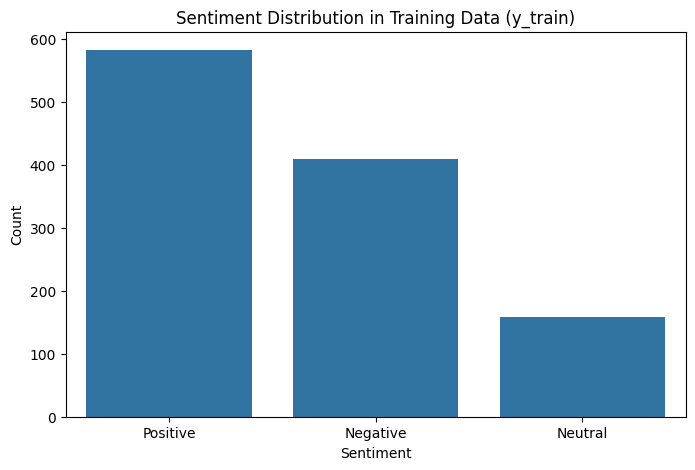

In [50]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title("Sentiment Distribution in Training Data (y_train)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()